**© Copyright AIDENTIFY. All rights reserved.**

# Part 3 | Session 21: GRPO 실습 — TRL GRPOTrainer로 직접 학습

---

### 📋 학습 목표

본 세션은 **GRPO 알고리즘을 코드로 직접 실행**해보는 실습 노트북입니다. 이론/배경은 Session 17·20에서 다뤘으므로, 본 세션은 핵심 원리만 짧게 짚고 곧바로 실습으로 들어갑니다.

- 🔹 GRPO 핵심 원리 (PPO와의 차이) 짧은 복습
- 🔹 GRPO 손실 함수 수식 이해
- 🔹 TRL `GRPOTrainer`로 수학 문제 학습 실행
- 🔹 학습 전후 모델 성능 비교, DPO vs GRPO 선택 가이드

### 📦 필요 라이브러리

```
torch, transformers, trl, datasets, peft
```

### ⏱️ 예상 소요 시간: 약 90분 (실제 학습 시간 포함)

### 🔗 선행 학습 (이론·배경은 여기서 끝)
- **Session 17** RL 개념 (PPO/DPO/GRPO 발전 흐름) — 본 세션은 이 내용 재설명 안 함
- **Session 20** DeepSeek R1 사례 (R1 학습 파이프라인 분석) — 본 세션은 재설명 안 함
- **Session 20b** Rejection Sampling + SFT 실습

> 💡 본 노트북은 **실습 전용**입니다. 이론을 한 번 더 보려면 17번·20번 노트북을 참조하세요.

---

In [1]:
# 💡 setup.sh 실행했으면 이 셀은 건너뛰세요 (참고용 — 본 노트북이 필요로 하는 패키지)
# 필수 라이브러리 설치
# !pip install -q trl>=0.15.0 transformers>=4.46.0 datasets accelerate peft bitsandbytes torch

In [2]:
import torch
import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────
# vLLM 제외 설정 (이 노트북 전용)
# 이 환경의 vLLM은 Session 25(vLLM 서빙) 전용으로 설치돼 있고 CUDA 13 빌드라,
# CUDA 12.8 기반 PyTorch/TRL 스택과 충돌합니다(libcudart.so.13 / GuidedDecodingParams).
# GRPO 학습 자체는 vLLM 없이 동작하므로, TRL이 vLLM을 임포트하지 않도록 숨깁니다.
# (반드시 `from trl import ...` 보다 먼저 실행되어야 합니다)
import importlib.metadata as _ilm
_orig_version = _ilm.version
def _hide_vllm(name, *args, **kwargs):
    if name == "vllm":
        raise _ilm.PackageNotFoundError(name)
    return _orig_version(name, *args, **kwargs)
_ilm.version = _hide_vllm
# ──────────────────────────────────────────────────────────────

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch 버전: 2.11.0+cu128
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 3070
GPU 메모리: 8.2 GB


---
## 1️⃣ GRPO 핵심 원리

### PPO와의 핵심 차이점

**PPO (Proximal Policy Optimization):**
- 각 상태(state)에 대해 **Critic 네트워크(Value function)**가 baseline을 제공
- Advantage = Reward - Value(state)
- Critic 네트워크는 Policy 모델과 동일한 크기 → **메모리 2배 필요**

**GRPO (Group Relative Policy Optimization):**
- Critic 네트워크를 **완전히 제거** (Critic-free)
- 대신 **그룹 샘플링(Group Sampling)**을 통해 baseline을 추정
- 하나의 질문에 대해 **G개의 응답을 샘플링**하고, 그룹 내 상대적 보상으로 advantage 계산

### Critic-free 방식의 직관

PPO에서 Critic이 하는 역할은 "이 상태에서 평균적으로 얼마나 좋은 보상을 받는가"를 추정하는 것입니다.

GRPO는 이를 **같은 질문에 대한 여러 응답의 평균 보상**으로 대체합니다:

```
PPO:  baseline = V(state)          ← Critic 네트워크가 추정
GRPO: baseline = mean(rewards)     ← 그룹 내 평균 보상으로 대체
```

### Group Sampling & Relative Reward

1. 하나의 질문 q에 대해 **G개의 응답** {o₁, o₂, ..., o_G}를 현재 정책에서 샘플링
2. 각 응답에 대해 보상 함수로 **보상 계산**: {r₁, r₂, ..., r_G}
3. 그룹 내 보상을 **정규화**: Âᵢ = (rᵢ - mean(r)) / std(r)
4. 정규화된 advantage로 **정책 업데이트**

---
## 2️⃣ GRPO 수식 설명

### GRPO Loss Function

GRPO의 목적 함수(objective)는 다음과 같습니다:

$$
J_{GRPO}(\theta) = \mathbb{E}_{q \sim P(Q), \{o_i\}_{i=1}^{G} \sim \pi_{\theta_{old}}(\cdot|q)}
\left[
\frac{1}{G} \sum_{i=1}^{G}
\min\left(
\frac{\pi_\theta(o_i|q)}{\pi_{\theta_{old}}(o_i|q)} \hat{A}_i,\;
\text{clip}\left(\frac{\pi_\theta(o_i|q)}{\pi_{\theta_{old}}(o_i|q)}, 1-\epsilon, 1+\epsilon\right) \hat{A}_i
\right)
- \beta \, D_{KL}(\pi_\theta \| \pi_{ref})
\right]
$$

### Advantage 계산 (핵심!)

PPO와 달리 **Critic 없이** advantage를 계산합니다:

$$
\hat{A}_i = \frac{r_i - \text{mean}(\{r_1, r_2, ..., r_G\})}{\text{std}(\{r_1, r_2, ..., r_G\})}
$$

여기서:
- $r_i$: i번째 응답의 보상 점수
- $G$: 그룹 크기 (보통 4~64)
- 정규화를 통해 **상대적 품질**을 측정

### 각 구성 요소의 역할

| 구성 요소 | 수식 | 역할 |
|----------|------|------|
| Ratio | $\frac{\pi_\theta(o_i|q)}{\pi_{\theta_{old}}(o_i|q)}$ | 정책 변화량 측정 |
| Clipping | $\text{clip}(\cdot, 1-\epsilon, 1+\epsilon)$ | 급격한 정책 변화 방지 |
| Advantage | $\hat{A}_i$ | 그룹 내 상대적 품질 |
| KL Penalty | $\beta \, D_{KL}$ | 참조 모델로부터의 이탈 제한 |

### KL Divergence 항

GRPO는 토큰 레벨에서 KL divergence를 계산합니다:

$$
D_{KL}(\pi_\theta \| \pi_{ref}) = \frac{\pi_{ref}(o_i|q)}{\pi_\theta(o_i|q)} - \log\frac{\pi_{ref}(o_i|q)}{\pi_\theta(o_i|q)} - 1
$$

이 방식은 일반적인 KL divergence의 근사치로, 학습 안정성을 높이는 역할을 합니다.

---
## 3️⃣ GRPO 실습: TRL GRPOTrainer 활용

이제 TRL 라이브러리의 `GRPOTrainer`를 사용하여 GRPO를 직접 실습해 보겠습니다.

**실습 목표:** 간단한 수학 문제에 대해 올바른 답을 생성하도록 GRPO로 학습

In [3]:
from datasets import Dataset

# 간단한 수학 문제 데이터셋 생성
# GRPOTrainer는 "prompt" 필드를 기대합니다
import random
random.seed(42)

prompts = []
answers = []

for _ in range(100):
    a = random.randint(1, 50)
    b = random.randint(1, 50)
    op = random.choice(['+', '-', '*'])
    
    if op == '+':
        answer = a + b
    elif op == '-':
        answer = a - b
    else:
        answer = a * b
    
    prompt = f"Calculate: {a} {op} {b} = ?"
    prompts.append([{"role": "user", "content": prompt}])
    answers.append(str(answer))

dataset = Dataset.from_dict({
    "prompt": prompts,
    "answer": answers
})

print(f"데이터셋 크기: {len(dataset)}")
print(f"\n예시 데이터:")
for i in range(3):
    print(f"  질문: {dataset[i]['prompt'][0]['content']}")
    print(f"  정답: {dataset[i]['answer']}")

데이터셋 크기: 100

예시 데이터:
  질문: Calculate: 41 + 8 = ?
  정답: 49
  질문: Calculate: 48 + 18 = ?
  정답: 66
  질문: Calculate: 15 * 9 = ?
  정답: 135


In [4]:
import re

def math_reward_func(completions, answer, **kwargs):
    """
    수학 문제에 대한 보상 함수
    
    - 정답이 응답에 포함되면 +1.0
    - 숫자가 포함되어 있지만 오답이면 -0.5
    - 숫자가 아예 없으면 -1.0
    """
    rewards = []
    for completion, ans in zip(completions, answer):
        # completion에서 텍스트 추출
        if isinstance(completion, list):
            # chat format: [{"role": "assistant", "content": "..."}]
            text = completion[-1]["content"] if completion else ""
        else:
            text = str(completion)
        
        # 정답 확인
        if ans in text:
            rewards.append(1.0)
        else:
            # 숫자가 포함되어 있는지 확인
            numbers = re.findall(r'-?\d+', text)
            if numbers:
                rewards.append(-0.5)
            else:
                rewards.append(-1.0)
    
    return rewards

# 보상 함수 테스트
test_completions = [
    [[{"role": "assistant", "content": "The answer is 75"}]],
    [[{"role": "assistant", "content": "The answer is 100"}]],
    [[{"role": "assistant", "content": "I don't know"}]]
]
test_answers = ["75", "50", "25"]

for comp, ans in zip(test_completions, test_answers):
    reward = math_reward_func(comp, [ans])
    content = comp[0][-1]['content'] if isinstance(comp[0], list) else comp[0]
    print(f"응답: '{content}' | 정답: {ans} | 보상: {reward[0]}")

응답: 'The answer is 75' | 정답: 75 | 보상: 1.0
응답: 'The answer is 100' | 정답: 50 | 보상: -0.5
응답: 'I don't know' | 정답: 25 | 보상: -1.0


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# 작은 모델 로드 (Qwen2.5-0.5B-Instruct)
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

print(f"모델 로딩 중: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

# padding token 설정
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"모델 파라미터 수: {model.num_parameters() / 1e6:.1f}M")
print(f"모델 로딩 완료!")

모델 로딩 중: Qwen/Qwen2.5-0.5B-Instruct


`torch_dtype` is deprecated! Use `dtype` instead!
Failed to load /home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/torchao/_C_cutlass_90a.abi3.so


모델 파라미터 수: 494.0M
모델 로딩 완료!


In [6]:
# GRPO 학습 전 모델 성능 확인
print("=" * 50)
print("GRPO 학습 전 모델 응답 확인")
print("=" * 50)

test_questions = [
    "Calculate: 12 + 8 = ?",
    "Calculate: 5 * 35 = ?",
    "Calculate: 40 - 17 = ?"
]

for q in test_questions:
    messages = [{"role": "user", "content": q}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            temperature=0.7,
            do_sample=True
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"\n질문: {q}")
    print(f"응답: {response[:100]}")

GRPO 학습 전 모델 응답 확인

질문: Calculate: 12 + 8 = ?
응답: The calculation \( 12 + 8 \) is straightforward:

\[
12 + 8 = 20
\]

So, the answer is \( 20 \).

질문: Calculate: 5 * 35 = ?
응답: The calculation \( 5 \times 35 \) is straightforward:

\[
5 \times 35 = 175
\]

So the result of \( 

질문: Calculate: 40 - 17 = ?
응답: Sure, let's solve the calculation step by step:

\[ 40 - 17 \]

First, we perform the subtraction:




In [ ]:
from trl import GRPOConfig, GRPOTrainer

# GRPO 학습 설정
grpo_config = GRPOConfig(
    output_dir="./grpo_output",
    
    # GRPO 핵심 하이퍼파라미터
    num_generations=4,            # G: 그룹 크기 (질문당 생성할 응답 수)
    max_completion_length=128,    # 생성 최대 토큰 수
    
    # 학습 설정
    num_train_epochs=5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    
    # PPO 스타일 파라미터
    beta=0.1,                     # KL penalty 계수
    
    # 최적화 설정
    bf16=True,
    logging_steps=5,
    save_strategy="no",           # 실습에서는 저장 생략
    
    # 기타 설정
    report_to="none",
    log_level="warning",
)

print("GRPO 설정 완료!")
print(f"  - 그룹 크기 (num_generations): {grpo_config.num_generations}")
print(f"  - KL penalty (beta): {grpo_config.beta}")
print(f"  - 학습률: {grpo_config.learning_rate}")
print(f"  - 최대 생성 길이: {grpo_config.max_completion_length}")

GRPO 설정 완료!
  - 그룹 크기 (num_generations): 4
  - KL penalty (beta): 0.1
  - 학습률: 5e-06
  - 최대 생성 길이: 128


In [8]:
# GRPOTrainer 초기화 및 학습
trainer = GRPOTrainer(
    model=model,
    reward_funcs=math_reward_func,
    args=grpo_config,
    train_dataset=dataset,
    processing_class=tokenizer,
)

print("GRPOTrainer 초기화 완료!")
print("\nGRPO 학습을 시작합니다...")
print("(GPU 환경에 따라 수 분에서 수십 분이 소요될 수 있습니다)")

The model is already on multiple devices. Skipping the move to device specified in `args`.


GRPOTrainer 초기화 완료!

GRPO 학습을 시작합니다...
(GPU 환경에 따라 수 분에서 수십 분이 소요될 수 있습니다)


In [9]:
# 학습 실행
train_result = trainer.train()

print("\n학습 완료!")
print(f"  - Total steps: {train_result.global_step}")
print(f"  - Training loss: {train_result.training_loss:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
5,0.088800
10,0.033000
15,0.100200
20,0.194300
25,0.047600
30,0.084100
35,0.025500
40,0.184000
45,0.374200
50,0.303900



학습 완료!
  - Total steps: 50
  - Training loss: 0.1436


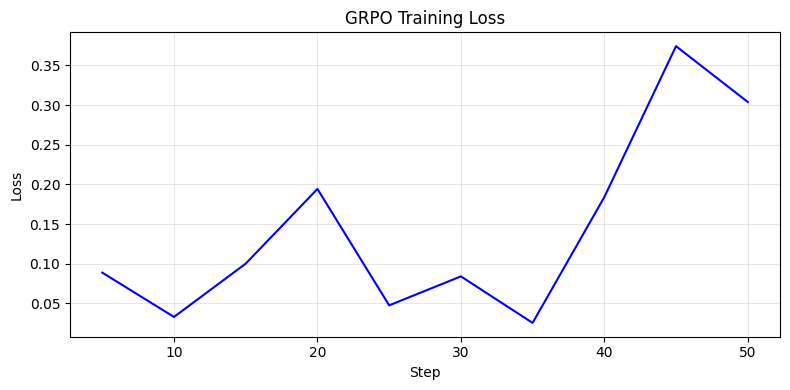

In [10]:
# 학습 로그 시각화
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# loss 추출
steps = []
losses = []
for log in log_history:
    if 'loss' in log:
        steps.append(log.get('step', 0))
        losses.append(log['loss'])

if losses:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(steps, losses, 'b-', linewidth=1.5)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('GRPO Training Loss')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("학습 로그에서 loss 정보를 찾을 수 없습니다.")
    print("로그 키:", [list(log.keys()) for log in log_history[:3]])

In [11]:
# GRPO 학습 후 모델 성능 확인
print("=" * 50)
print("GRPO 학습 후 모델 응답 확인")
print("=" * 50)

for q in test_questions:
    messages = [{"role": "user", "content": q}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            temperature=0.7,
            do_sample=True
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"\n질문: {q}")
    print(f"응답: {response[:100]}")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Caching is incompatible with gradient checkpointing in Qwen2DecoderLayer. Setting `past_key_values=None`.


GRPO 학습 후 모델 응답 확인

질문: Calculate: 12 + 8 = ?
응답: Sure

...



  �、“ �/ / code syntax) =  "4、《安全生产建设社会主义社会主义社会主义建设/API/API/API/API/API/API/API/API/API

질문: Calculate: 5 * 35 = ?
응답: To reduce code            
        

    var 《企业代码 


...

] =      1、《关于建设工程中/*****
* Code/API/API/

질문: Calculate: 40 - 17 = ?
응답: Sure

          
                                                                   code/API/API/API


---
## 4️⃣ 결과 분석 및 DPO vs GRPO 비교

### GRPO 학습 결과 분석

위 실습에서 확인할 수 있는 핵심 포인트:

1. **보상 함수 기반 학습:** 별도의 선호 데이터 없이 규칙 기반 보상 함수만으로 학습 가능
2. **그룹 샘플링 효과:** 같은 질문에 대한 여러 응답을 비교하며 상대적으로 좋은 응답을 강화
3. **메모리 효율성:** Critic 네트워크 없이도 효과적인 RL 학습 수행

In [12]:
# DPO vs GRPO 정량적 비교 (개념 정리)
print("=" * 60)
print("DPO vs GRPO 비교 정리")
print("=" * 60)

comparison = {
    "항목": [
        "학습 데이터",
        "보상 모델",
        "Critic 네트워크",
        "메모리 요구량",
        "보상 함수 유연성",
        "추론 능력 강화",
        "구현 복잡도",
        "대표 모델",
    ],
    "DPO": [
        "선호 쌍 (chosen/rejected)",
        "불필요 (암묵적)",
        "불필요",
        "중간 (ref model 필요)",
        "낮음 (쌍 데이터 의존)",
        "보통",
        "낮음",
        "Llama 2, Zephyr",
    ],
    "GRPO": [
        "프롬프트 + 보상 함수",
        "규칙 기반 가능",
        "불필요 (Critic-free)",
        "중간 (ref model 필요)",
        "높음 (다양한 보상 설계 가능)",
        "우수 (CoT 자연 발현)",
        "중간",
        "DeepSeek-R1",
    ]
}

print(f"{'항목':<20} {'DPO':<30} {'GRPO':<30}")
print("-" * 80)
for i in range(len(comparison["항목"])):
    print(f"{comparison['항목'][i]:<20} {comparison['DPO'][i]:<30} {comparison['GRPO'][i]:<30}")

DPO vs GRPO 비교 정리
항목                   DPO                            GRPO                          
--------------------------------------------------------------------------------
학습 데이터               선호 쌍 (chosen/rejected)         프롬프트 + 보상 함수                  
보상 모델                불필요 (암묵적)                      규칙 기반 가능                      
Critic 네트워크          불필요                            불필요 (Critic-free)             
메모리 요구량              중간 (ref model 필요)              중간 (ref model 필요)             
보상 함수 유연성            낮음 (쌍 데이터 의존)                  높음 (다양한 보상 설계 가능)             
추론 능력 강화             보통                             우수 (CoT 자연 발현)                
구현 복잡도               낮음                             중간                            
대표 모델                Llama 2, Zephyr                DeepSeek-R1                   


### DPO vs GRPO: 언제 무엇을 선택할까?

**DPO를 선택하는 경우:**
- 고품질 선호 데이터가 이미 확보된 경우
- 주관적 판단이 필요한 태스크 (창의적 글쓰기, 대화 스타일 등)
- 빠르고 간단한 정렬이 필요한 경우

**GRPO를 선택하는 경우:**
- 정답이 명확한 태스크 (수학, 코딩 등)
- 규칙 기반 보상 함수를 설계할 수 있는 경우
- 모델의 추론 능력을 강화하고 싶은 경우
- 선호 데이터 수집이 어려운 경우

**실무적 조합:**
- DeepSeek-R1은 SFT → GRPO → Rejection Sampling → SFT → GRPO 순으로 반복 적용
- DPO와 GRPO를 순차적으로 적용하는 것도 가능 (예: DPO로 기본 정렬 후 GRPO로 추론 강화)

### 핵심 요약

| 핵심 개념 | 설명 |
|----------|------|
| **GRPO** | PPO에서 Critic을 제거하고, 그룹 내 상대적 보상으로 대체한 RL 알고리즘 |
| **Group Sampling** | 하나의 질문에 대해 여러 응답을 생성하여 비교하는 방식 |
| **Relative Advantage** | 그룹 내 보상의 평균/표준편차로 정규화한 상대적 이점 |
| **Critic-free** | Value function 네트워크 없이 RL 학습 → 메모리 효율적 |
| **Rule-based Reward** | 사람의 판단 없이 규칙으로 보상을 부여하는 방식 |
| **CoT 자연 발현** | GRPO 학습 중 모델이 스스로 사고 과정을 생성하기 시작하는 현상 |

In [13]:
# 메모리 정리
import gc

del model, trainer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU 메모리 해제 완료")

print("\n실습을 마칩니다. 수고하셨습니다!")

GPU 메모리 해제 완료

실습을 마칩니다. 수고하셨습니다!
